In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
data = {
    "StudyHours": [2, 3, 4, 5, 6, 7, 8, 1, 4, 6,
                   3, 5, 7, 2, 8, 5, 6, 4, 7, 3],
    
    "Attendance": [65, 70, 75, 80, 85, 90, 92, 60, 78, 88,
                   72, 82, 91, 64, 95, 79, 86, 76, 89, 68],
    
    "PreviousScore": [55, 60, 65, 70, 75, 80, 85, 50, 68, 78,
                      62, 72, 81, 54, 90, 69, 77, 66, 83, 58],
    
    "AssignmentScore": [60, 65, 70, 75, 80, 85, 90, 55, 72, 82,
                        67, 77, 86, 58, 94, 74, 81, 71, 88, 63],
    
    "Participation": [50, 55, 60, 65, 70, 75, 80, 45, 65, 72,
                      58, 68, 78, 48, 85, 64, 73, 62, 79, 53],
    
    "FinalScore": [58, 64, 70, 76, 82, 88, 93, 52, 73, 84,
                   66, 78, 89, 55, 96, 73, 82, 70, 91, 62]
}

df = pd.DataFrame(data)

df


,StudyHours,Attendance,PreviousScore,AssignmentScore,Participation,FinalScore
0,2,65,55,60,50,58
1,3,70,60,65,55,64
2,4,75,65,70,60,70
3,5,80,70,75,65,76
4,6,85,75,80,70,82
5,7,90,80,85,75,88
6,8,92,85,90,80,93
7,1,60,50,55,45,52
8,4,78,68,72,65,73
9,6,88,78,82,72,84


In [3]:
print("First 5 records:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()


First 5 records:


,StudyHours,Attendance,PreviousScore,AssignmentScore,Participation,FinalScore
0,2,65,55,60,50,58
1,3,70,60,65,55,64
2,4,75,65,70,60,70
3,5,80,70,75,65,76
4,6,85,75,80,70,82



Dataset Shape:
(20, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   StudyHours       20 non-null     int64
 1   Attendance       20 non-null     int64
 2   PreviousScore    20 non-null     int64
 3   AssignmentScore  20 non-null     int64
 4   Participation    20 non-null     int64
 5   FinalScore       20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB


In [4]:
print("Missing Values:")
print(df.isnull().sum())


Missing Values:
StudyHours         0
Attendance         0
PreviousScore      0
AssignmentScore    0
Participation      0
FinalScore         0
dtype: int64


In [5]:
X = df[
    [
        "StudyHours",
        "Attendance",
        "PreviousScore",
        "AssignmentScore",
        "Participation"
    ]
]

y = df["FinalScore"]

print("Input Features:")
display(X.head())

print("\nTarget Variable:")
display(y.head())


Input Features:


,StudyHours,Attendance,PreviousScore,AssignmentScore,Participation
0,2,65,55,60,50
1,3,70,60,65,55
2,4,75,65,70,60
3,5,80,70,75,65
4,6,85,75,80,70



Target Variable:


0    58
1    64
2    70
3    76
4    82
Name: FinalScore, dtype: int64

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (16, 5)
Testing data: (4, 5)


In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")


Linear Regression Model Trained Successfully!


In [8]:
y_pred = model.predict(X_test)

print("Actual Scores:")
print(y_test.values)

print("\nPredicted Scores:")
print(np.round(y_pred, 2))


Actual Scores:
[58 70 73 64]

Predicted Scores:
[58.04 71.29 74.82 64.01]


In [9]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("------------------------")
print("Mean Absolute Error :", round(mae, 2))
print("Mean Squared Error  :", round(mse, 2))
print("Root Mean Squared Error :", round(rmse, 2))
print("R2 Score            :", round(r2, 2))


Model Evaluation
------------------------
Mean Absolute Error : 0.79
Mean Squared Error  : 1.24
Root Mean Squared Error : 1.11
R2 Score            : 0.96


In [10]:
print("Model Coefficients")
print("------------------------")

for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.4f}")

print(f"\nIntercept: {model.intercept_:.4f}")


Model Coefficients
------------------------
StudyHours: 0.3334
Attendance: 0.2927
PreviousScore: -0.8790
AssignmentScore: 1.5291
Participation: 0.1840

Intercept: -14.2588


In [11]:
new_student = pd.DataFrame({
    "StudyHours": [6],
    "Attendance": [85],
    "PreviousScore": [75],
    "AssignmentScore": [80],
    "Participation": [70]
})

predicted_score = model.predict(new_student)

print("New Student Details")
print("------------------------")
display(new_student)

print(f"Predicted Final Score: {predicted_score[0]:.2f}")


New Student Details
------------------------


,StudyHours,Attendance,PreviousScore,AssignmentScore,Participation
0,6,85,75,80,70


Predicted Final Score: 81.91


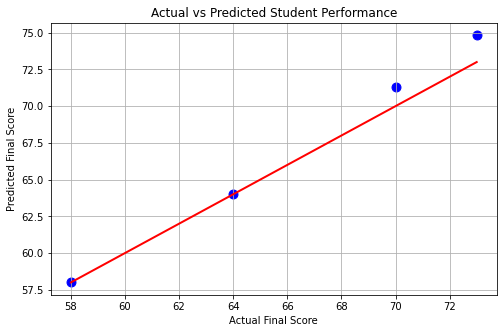

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, color="blue", s=80)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Student Performance")

plt.grid(True)
plt.show()


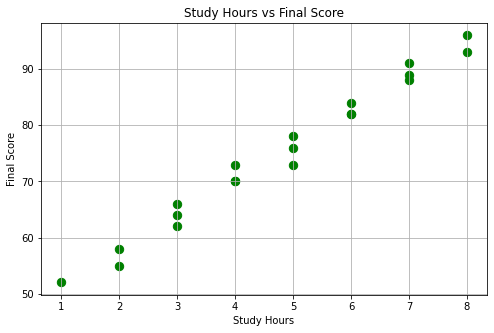

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["StudyHours"],
    df["FinalScore"],
    color="green",
    s=70
)

plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Study Hours vs Final Score")

plt.grid(True)
plt.show()


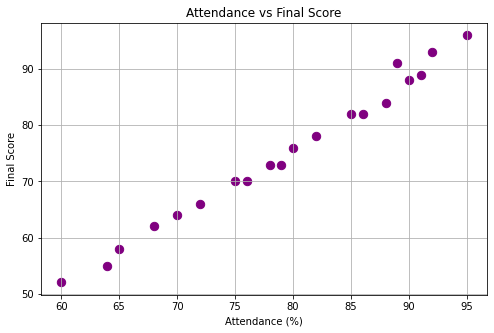

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Attendance"],
    df["FinalScore"],
    color="purple",
    s=70
)

plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")
plt.title("Attendance vs Final Score")

plt.grid(True)
plt.show()


STUDENT PERFORMANCE DATASET
 StudyHours  Attendance  PreviousScore  AssignmentScore  Participation  FinalScore
          2          65             55               60             50          58
          3          70             60               65             55          64
          4          75             65               70             60          70
          5          80             70               75             65          76
          6          85             75               80             70          82
          7          90             80               85             75          88
          8          92             85               90             80          93
          1          60             50               55             45          52
          4          78             68               72             65          73
          6          88             78               82             72          84
          3          72             62               67    

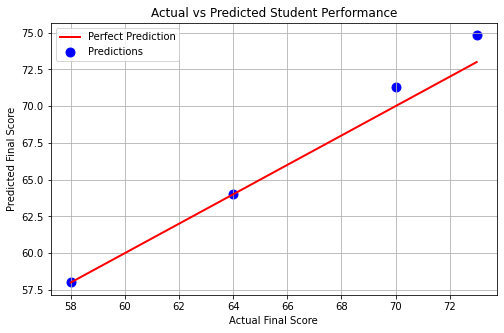

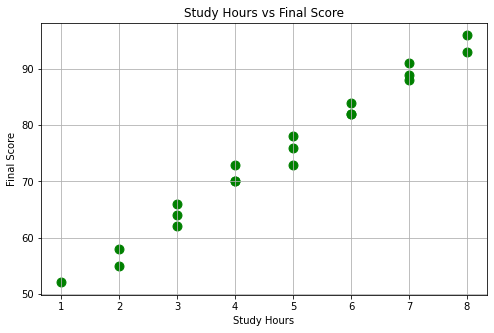

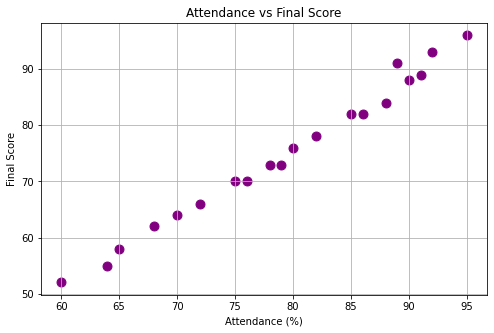


PROJECT COMPLETED SUCCESSFULLY!


In [15]:
# ============================================================
# STUDENT PERFORMANCE PREDICTION USING LINEAR REGRESSION
# ML MINI PROJECT
# ============================================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 2. CREATE DATASET
# ============================================================

data = {
    "StudyHours": [
        2, 3, 4, 5, 6, 7, 8, 1, 4, 6,
        3, 5, 7, 2, 8, 5, 6, 4, 7, 3
    ],

    "Attendance": [
        65, 70, 75, 80, 85, 90, 92, 60, 78, 88,
        72, 82, 91, 64, 95, 79, 86, 76, 89, 68
    ],

    "PreviousScore": [
        55, 60, 65, 70, 75, 80, 85, 50, 68, 78,
        62, 72, 81, 54, 90, 69, 77, 66, 83, 58
    ],

    "AssignmentScore": [
        60, 65, 70, 75, 80, 85, 90, 55, 72, 82,
        67, 77, 86, 58, 94, 74, 81, 71, 88, 63
    ],

    "Participation": [
        50, 55, 60, 65, 70, 75, 80, 45, 65, 72,
        58, 68, 78, 48, 85, 64, 73, 62, 79, 53
    ],

    "FinalScore": [
        58, 64, 70, 76, 82, 88, 93, 52, 73, 84,
        66, 78, 89, 55, 96, 73, 82, 70, 91, 62
    ]
}

df = pd.DataFrame(data)


# ============================================================
# 3. DISPLAY DATASET
# ============================================================

print("=" * 60)
print("STUDENT PERFORMANCE DATASET")
print("=" * 60)

print(df.to_string(index=False))


# ============================================================
# 4. CHECK DATASET
# ============================================================

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 5. SELECT FEATURES AND TARGET
# ============================================================

X = df[
    [
        "StudyHours",
        "Attendance",
        "PreviousScore",
        "AssignmentScore",
        "Participation"
    ]
]

y = df["FinalScore"]


# ============================================================
# 6. SPLIT DATA INTO TRAINING AND TESTING
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n" + "=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 7. CREATE AND TRAIN LINEAR REGRESSION MODEL
# ============================================================

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel trained successfully!")


# ============================================================
# 8. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 9. DISPLAY ACTUAL VS PREDICTED VALUES
# ============================================================

comparison = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": np.round(y_pred, 2)
})

print("\n" + "=" * 60)
print("ACTUAL VS PREDICTED SCORES")
print("=" * 60)

print(comparison.to_string(index=False))


# ============================================================
# 10. MODEL EVALUATION
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

print("Mean Absolute Error      :", round(mae, 2))
print("Mean Squared Error       :", round(mse, 2))
print("Root Mean Squared Error  :", round(rmse, 2))
print("R2 Score                 :", round(r2, 2))


# ============================================================
# 11. DISPLAY MODEL COEFFICIENTS
# ============================================================

print("\n" + "=" * 60)
print("MODEL COEFFICIENTS")
print("=" * 60)

for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature:20s}: {coefficient:.4f}")

print(f"\nIntercept             : {model.intercept_:.4f}")


# ============================================================
# 12. PREDICT PERFORMANCE OF A NEW STUDENT
# ============================================================

new_student = pd.DataFrame({
    "StudyHours": [6],
    "Attendance": [85],
    "PreviousScore": [75],
    "AssignmentScore": [80],
    "Participation": [70]
})

predicted_score = model.predict(new_student)[0]

print("\n" + "=" * 60)
print("NEW STUDENT PREDICTION")
print("=" * 60)

print("Study Hours       :", new_student["StudyHours"].iloc[0])
print("Attendance        :", new_student["Attendance"].iloc[0], "%")
print("Previous Score    :", new_student["PreviousScore"].iloc[0])
print("Assignment Score  :", new_student["AssignmentScore"].iloc[0])
print("Participation     :", new_student["Participation"].iloc[0])

print("\nPredicted Final Score:", round(predicted_score, 2))


# ============================================================
# 13. VISUALIZATION - ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    color="blue",
    s=80,
    label="Predictions"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Student Performance")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 14. VISUALIZATION - STUDY HOURS VS FINAL SCORE
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["StudyHours"],
    df["FinalScore"],
    color="green",
    s=80
)

plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Study Hours vs Final Score")
plt.grid(True)

plt.show()


# ============================================================
# 15. VISUALIZATION - ATTENDANCE VS FINAL SCORE
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Attendance"],
    df["FinalScore"],
    color="purple",
    s=80
)

plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")
plt.title("Attendance vs Final Score")
plt.grid(True)

plt.show()


# ============================================================
# END OF PROJECT
# ============================================================

print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 60)
